In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np

In [2]:
# 2. Load the dataset into dataframe
df = pd.read_csv('C:/Users/Aryan/OneDrive/Desktop/Aryan/TE/DSBDAL/Data Set/student_performance11.csv')
print(df)

    math score  Reading Score  Writing Score  Placement Score  Club join Date
0         98.0           78.0           45.0             99.0          2011.3
1         25.0           50.0           34.0             67.2          2022.7
2         37.0           49.0           45.0             23.4          2022.6
3          NaN           48.0            NaN             34.7          2023.1
4         55.0           23.0           43.0              NaN          2023.2
5         65.0           45.0           21.0             23.0          2022.5
6         34.0           56.0           34.0             45.6          2002.6
7         78.0           34.0           56.0             78.9          2003.6
8         23.0           45.0           78.0             34.2          2003.4
9         12.0            NaN           65.0             35.6             NaN
10        34.0           23.0           43.0             67.9          2005.8
11        56.0           34.0           45.0             45.7   

In [3]:
# 2. Check the dimensions of the dataframe 
print("Dataset Shape:", df.shape)

Dataset Shape: (30, 5)


In [4]:
# 3. Check for missing values in each column 
print("\nInitial Missing values count:\n", df.isnull().sum())


Initial Missing values count:
 math score         3
Reading Score      2
Writing Score      3
Placement Score    4
Club join Date     3
dtype: int64


In [5]:
df.isnull()

,math score,Reading Score,Writing Score,Placement Score,Club join Date
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,True,False,True,False,False
4,False,False,False,True,False
5,False,False,False,False,False
6,False,False,False,False,False
7,False,False,False,False,False
8,False,False,False,False,False
9,False,True,False,False,True


In [6]:
# Interpolate missing math scores 
df['math score'] = df['math score'].interpolate()

In [7]:
df.isnull().sum()

math score         0
Reading Score      2
Writing Score      3
Placement Score    4
Club join Date     3
dtype: int64

In [8]:
df['Reading Score'] = df['Reading Score'].fillna(df['Reading Score'].mean())

In [9]:
# Fill placement_score using backward fill (bfill) 
# Note: Using column name from your CSV file
df['Placement Score'] = df['Placement Score'].bfill()

In [10]:
df.isnull().sum()

math score         0
Reading Score      0
Writing Score      3
Placement Score    0
Club join Date     3
dtype: int64

In [11]:
df['Writing Score'] = df['Writing Score'].ffill()

In [12]:
df.isnull().sum()

math score         0
Reading Score      0
Writing Score      0
Placement Score    0
Club join Date     3
dtype: int64

In [13]:
df['Club join Date'] = df['Club join Date'].replace(to_replace=np.nan, value=2019)

In [14]:
df.isnull().sum()

math score         0
Reading Score      0
Writing Score      0
Placement Score    0
Club join Date     0
dtype: int64

In [15]:
df.dtypes

math score         float64
Reading Score      float64
Writing Score      float64
Placement Score    float64
Club join Date     float64
dtype: object

In [16]:
# Check the data types and convert into appropriate types
df['math score'] = df['math score'].astype('int64')
df['Reading Score'] = df['Reading Score'].astype('int64')
df['Writing Score'] = df['Writing Score'].astype('int64')
df['Placement Score'] = df['Placement Score'].astype('int64')
df['Club join Date'] = df['Club join Date'].astype('int64')
print(df.dtypes)

math score         int64
Reading Score      int64
Writing Score      int64
Placement Score    int64
Club join Date     int64
dtype: object


<Axes: >

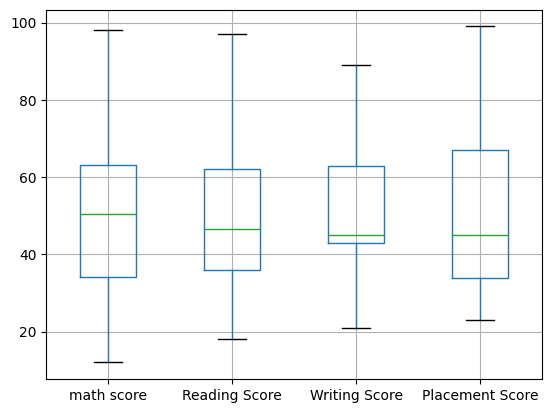

In [17]:
columns = ['math score', 'Reading Score', 'Writing Score', 'Placement Score']
df.boxplot(columns)


In [18]:
np.where(df['math score']< 60 )

(array([ 1,  2,  3,  4,  6,  8,  9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 26, 27, 28], dtype=int64),)

In [19]:
np.where(df['math score'] > 80 )

(array([ 0, 23, 24], dtype=int64),)

In [20]:
np.where(df['Reading Score']< 75 )

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
        19, 20, 21, 22, 25, 26, 27, 28, 29], dtype=int64),)

In [21]:
np.where(df['Writing Score']< 75 )

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  9, 10, 11, 12, 13, 15, 16, 17, 18,
        19, 20, 21, 24, 25, 26, 27, 28, 29], dtype=int64),)

In [22]:
np.where(df['Writing Score'] > 80 )

(array([14, 22, 23], dtype=int64),)

In [23]:
np.where(df['Placement Score'] < 75 )

(array([ 1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        21, 22, 23, 24, 25, 26, 27], dtype=int64),)

In [24]:
np.where(df['Placement Score'] > 80 )

(array([ 0, 19, 20, 28, 29], dtype=int64),)

In [25]:
# Filtering the dataset based on academic performance criteria
# Note: Ensure the '&' operator is used between EVERY condition set.
new_df = df[
    (df['math score'] >= 60) & (df['math score'] <= 80) &
    (df['Reading Score'] >= 75) & (df['Reading Score'] <= 95) &
    (df['Writing Score'] >= 60) & (df['Writing Score'] <= 80) &  # Added &
    (df['Placement Score'] >= 75) & (df['Placement Score'] <= 100) &  # Added &
    (df['Club join Date'] >= 2018) & (df['Club join Date'] <= 2021)   # Fixed range logic
].copy()

print("Shape of dataset after strict filtering:", new_df.shape)
print("\nFirst 5 rows of cleaned data:\n", new_df.head())

Shape of dataset after strict filtering: (0, 5)

First 5 rows of cleaned data:
 Empty DataFrame
Columns: [math score, Reading Score, Writing Score, Placement Score, Club join Date]
Index: []


In [26]:
new_df

,math score,Reading Score,Writing Score,Placement Score,Club join Date


In [ ]:
# =============================================================================
# IMPORTANT NOTES FOR ORAL EXAM - DATA WRANGLING II
# =============================================================================

# --------------------------------------------------------------------------
# WHAT IS DATA WRANGLING?
# --------------------------------------------------------------------------
# Data Wrangling is the process of cleaning, transforming, and organizing
# raw/messy data into a proper format so it can be used for analysis or
# machine learning models.
# Raw data often has: missing values, wrong data types, outliers, etc.
# Data Wrangling fixes all these issues step by step.

# --------------------------------------------------------------------------
# DATASET USED - STUDENT PERFORMANCE DATASET
# --------------------------------------------------------------------------
# This is a custom dataset with 30 rows and 5 columns:
#   - math score       : Student's math exam score
#   - Reading Score    : Student's reading exam score
#   - Writing Score    : Student's writing exam score
#   - Placement Score  : Student's placement test score
#   - Club join Date   : Year the student joined a club
# The dataset has missing values (NaN) in multiple columns.

# --------------------------------------------------------------------------
# LIBRARIES USED
# --------------------------------------------------------------------------
# pandas (pd) : For loading, exploring, and manipulating data using DataFrames.
# numpy  (np) : For numerical operations; np.nan represents a missing value.

# --------------------------------------------------------------------------
# STEP 1 - LOADING DATA
# --------------------------------------------------------------------------
# pd.read_csv() : Reads a CSV file and loads it into a Pandas DataFrame.
# df.shape      : Returns (rows, columns) - here it is (30, 5).

# --------------------------------------------------------------------------
# STEP 2 - CHECKING MISSING VALUES
# --------------------------------------------------------------------------
# df.isnull()       : Returns a DataFrame of True/False.
#                     True = value is missing (NaN), False = value is present.
# df.isnull().sum() : Counts the number of missing values per column.
#                     In this dataset:
#                       math score       -> 3 missing
#                       Reading Score    -> 2 missing
#                       Writing Score    -> 3 missing
#                       Placement Score  -> 4 missing
#                       Club join Date   -> 3 missing

# --------------------------------------------------------------------------
# STEP 3 - HANDLING MISSING VALUES (5 Different Methods Used)
# --------------------------------------------------------------------------

# METHOD 1 - interpolate() for 'math score':
#   df['math score'] = df['math score'].interpolate()
#   - Fills missing values by calculating the average between
#     the previous and next value (linear interpolation by default).
#   - Example: values are 37, NaN, 55 -> fills NaN with (37+55)/2 = 46.
#   - Best for numerical columns where values follow a trend/pattern.

# METHOD 2 - fillna(mean()) for 'Reading Score':
#   df['Reading Score'] = df['Reading Score'].fillna(df['Reading Score'].mean())
#   - Calculates the average (mean) of all non-missing values in the column.
#   - Fills all NaN values with that mean.
#   - Best for numerical columns where data is roughly evenly distributed.

# METHOD 3 - bfill() for 'Placement Score':
#   df['Placement Score'] = df['Placement Score'].bfill()
#   - bfill = Backward Fill.
#   - Fills a missing value with the NEXT available value below it.
#   - Example: values are NaN, 45.0 -> fills NaN with 45.0.
#   - Useful when the next value is a better estimate than the previous one.

# METHOD 4 - ffill() for 'Writing Score':
#   df['Writing Score'] = df['Writing Score'].ffill()
#   - ffill = Forward Fill.
#   - Fills a missing value with the PREVIOUS available value above it.
#   - Example: values are 56.0, NaN -> fills NaN with 56.0.
#   - Useful when the previous value is a good estimate for the missing one.

# METHOD 5 - replace() with a fixed value for 'Club join Date':
#   df['Club join Date'] = df['Club join Date'].replace(to_replace=np.nan, value=2019)
#   - Replaces all NaN values with a specific fixed value (here: 2019).
#   - Used when we know a reasonable default value to substitute.
#   - Here 2019 is used as a default year for students with unknown join dates.

# --------------------------------------------------------------------------
# STEP 4 - CHANGING DATA TYPES
# --------------------------------------------------------------------------
# After filling missing values, all columns are of type float64 (decimal).
# Scores and dates should be integers, so we convert them.
#
# df['math score'] = df['math score'].astype('int64')
# - astype() converts the data type of a column.
# - 'int64' means 64-bit integer (whole numbers).
# - We do this for all 5 columns to make the data clean and meaningful.
#
# Why convert? Because a score like 45.0 should be 45, and a year like
# 2019.0 should be 2019. Integers are more appropriate here.

# --------------------------------------------------------------------------
# STEP 5 - BOXPLOT (Data Visualization for Outlier Detection)
# --------------------------------------------------------------------------
# df.boxplot(columns)
# - A boxplot is a graph that shows the distribution of data.
# - It shows: minimum, Q1 (25%), median (50%), Q3 (75%), maximum.
# - Points outside the whiskers are called OUTLIERS.
# - Here we plot math score, Reading Score, Writing Score, Placement Score.
# - This helps us visually identify if any scores are unusually high or low.

# --------------------------------------------------------------------------
# STEP 6 - np.where() (Finding Outliers / Condition-based Indexing)
# --------------------------------------------------------------------------
# np.where(condition)
# - Returns the indices (row numbers) where the condition is True.
# - Example: np.where(df['math score'] < 60)
#   -> Returns row numbers where math score is less than 60.
# - This helps identify which students scored below or above a threshold.
# - Used here to find students with very low or very high scores
#   (potential outliers or students of interest).

# --------------------------------------------------------------------------
# STEP 7 - FILTERING THE DATASET
# --------------------------------------------------------------------------
# new_df = df[(condition1) & (condition2) & ...].copy()
# - Filters rows that satisfy ALL given conditions simultaneously.
# - '&' is used to combine multiple conditions (AND logic).
# - Each condition is wrapped in () because of Python operator precedence.
# - .copy() creates a new independent copy so changes don't affect original df.
#
# Conditions applied:
#   math score       : between 60 and 80
#   Reading Score    : between 75 and 95
#   Writing Score    : between 60 and 80
#   Placement Score  : between 75 and 100
#   Club join Date   : between 2018 and 2021
#
# This gives us a filtered dataset of students who performed within
# acceptable academic ranges.

# --------------------------------------------------------------------------
# KEY TERMS TO REMEMBER
# --------------------------------------------------------------------------
# NaN           : Not a Number - represents a missing value.
# interpolate() : Fills missing values using linear interpolation
#                 (average of neighbors).
# fillna(mean)  : Fills missing values with the column's average.
# ffill()       : Forward Fill - copies the previous row's value.
# bfill()       : Backward Fill - copies the next row's value.
# replace()     : Replaces a specific value (like NaN) with another value.
# astype()      : Converts the data type of a column.
# boxplot()     : Visual graph to see data distribution and outliers.
# np.where()    : Returns row indices where a condition is True.
# .copy()       : Creates an independent copy of a DataFrame.
# axis=1        : Refers to columns; axis=0 refers to rows.
# inplace=True  : Applies changes directly to the DataFrame.

# --------------------------------------------------------------------------
# POSSIBLE ORAL EXAM QUESTIONS & ANSWERS
# --------------------------------------------------------------------------
# Q: What is Data Wrangling?
# A: It is the process of cleaning and transforming raw, messy data into a
#    clean, usable format for analysis or machine learning.

# Q: What dataset is used here?
# A: Student Performance dataset with 30 rows and 5 columns:
#    math score, Reading Score, Writing Score, Placement Score, Club join Date.

# Q: How many missing values were there initially?
# A: math score=3, Reading Score=2, Writing Score=3,
#    Placement Score=4, Club join Date=3. Total = 15 missing values.

# Q: What is the difference between ffill and bfill?
# A: ffill (forward fill) copies the value from the PREVIOUS row.
#    bfill (backward fill) copies the value from the NEXT row.

# Q: Why do we use interpolate() instead of fillna(mean)?
# A: interpolate() is better when data follows a trend or pattern,
#    because it estimates the missing value based on neighboring values.
#    fillna(mean) is better when data is randomly distributed.

# Q: What does np.where() do?
# A: It returns the row indices (positions) where a given condition is True.
#    Used to find rows with values above or below a threshold.

# Q: Why do we use .copy() when filtering?
# A: To create an independent copy of the filtered data.
#    Without .copy(), changes to new_df might affect the original df.

# Q: Why do we convert float columns to int64?
# A: After filling missing values, columns become float (e.g., 45.0).
#    Scores and years should be whole numbers (integers), so we convert
#    them using astype('int64') for cleaner and more meaningful data.

# Q: What is a boxplot and why is it used?
# A: A boxplot is a graph showing data distribution.
#    It displays min, Q1, median, Q3, max, and outliers.
#    We use it to visually detect outliers in score columns.
# =============================================================================
